# ECE1508 Project Notebook  
## Robust 3D Vessel Aneurysm Classification: Voxels (3D CNN) vs. Points (PointNet)

This notebook implements the project:

- **Dataset:** MedMNIST `VesselMNIST3D` (28×28×28), binary classification  
- **Pipelines:**  
  1. voxel-based **3D CNN** on the original volume  
  2. point-based **PointNet** on point clouds converted from the same volume  
- **Metrics:** **AUROC** (primary) and accuracy  
- **Robustness benchmark:** clean data vs. controlled **rotation** and **additive noise** shifts at multiple severities  
- **Training settings:** clean training vs. strong train-time robustness augmentation  
- **Point ablations:** `xyz` vs. `xyz+I`, and `N=512` vs. `N=1024`  
- **Milestone 4:** optional **test-time augmentation (TTA)** and clean–robust trade-off analysis

### Expected outputs
This notebook saves:
- trained checkpoints
- per-epoch histories
- robustness benchmark tables
- clean-vs-shift performance drop tables
- plots for AUROC / accuracy vs. severity


In [ ]:

#   1) Install dependencies
!pip -q install -U medmnist scikit-learn pandas matplotlib tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.

In [ ]:

#   2) Imports, paths, and reproducibility
import os
import math
import json
import time
import copy
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, accuracy_score

import medmnist
from medmnist import INFO, VesselMNIST3D

SEED = 42

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

ROOT_DIR = Path("/content/vesselmnist3d_project")
DATA_DIR = ROOT_DIR / "data"
OUT_DIR = ROOT_DIR / "outputs"
CKPT_DIR = OUT_DIR / "checkpoints"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"

for p in [ROOT_DIR, DATA_DIR, OUT_DIR, CKPT_DIR, FIG_DIR, TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

info = INFO["vesselmnist3d"]
print(json.dumps({
    "python_class": info["python_class"],
    "task": info["task"],
    "labels": info["label"],
    "n_samples": info["n_samples"],
    "n_channels": info["n_channels"],
}, indent=2))


Using device: cuda
GPU: Tesla T4
{
  "python_class": "VesselMNIST3D",
  "task": "binary-class",
  "labels": {
    "0": "vessel",
    "1": "aneurysm"
  },
  "n_samples": {
    "train": 1335,
    "val": 191,
    "test": 382
  },
  "n_channels": 1
}


In [ ]:

#   3) Project configuration
@dataclass
class TrainConfig:
    batch_size: int = 64
    num_workers: int = 2
    epochs: int = 25
    lr: float = 1e-3
    weight_decay: float = 1e-4
    patience: int = 6
    use_amp: bool = True
    robust_train: bool = False
    train_rotation_deg: float = 25.0
    train_noise_std: float = 0.08

@dataclass
class PointConfig:
    num_points: int = 1024
    include_intensity: bool = True
    threshold: float = 0.10
    min_candidate_ratio: float = 0.25
    weighted_sampling: bool = True

@dataclass
class TTAConfig:
    enabled: bool = False
    reps: int = 8
    rotation_deg: float = 10.0
    noise_std: float = 0.03

BASE_TRAIN_CFG = TrainConfig()
ROBUST_TRAIN_CFG = TrainConfig(robust_train=True)

POINT_MAIN_CFG = PointConfig(num_points=1024, include_intensity=True)
POINT_ABLATIONS = [
    PointConfig(num_points=512, include_intensity=False),
    PointConfig(num_points=512, include_intensity=True),
    PointConfig(num_points=1024, include_intensity=True),
]

ROTATION_SEVERITIES = [0.0, 15.0, 30.0, 45.0]
NOISE_SEVERITIES = [0.0, 0.03, 0.06, 0.10]

print("Base train config:", asdict(BASE_TRAIN_CFG))
print("Robust train config:", asdict(ROBUST_TRAIN_CFG))
print("Main point config:", asdict(POINT_MAIN_CFG))


Base train config: {'batch_size': 64, 'num_workers': 2, 'epochs': 25, 'lr': 0.001, 'weight_decay': 0.0001, 'patience': 6, 'use_amp': True, 'robust_train': False, 'train_rotation_deg': 25.0, 'train_noise_std': 0.08}
Robust train config: {'batch_size': 64, 'num_workers': 2, 'epochs': 25, 'lr': 0.001, 'weight_decay': 0.0001, 'patience': 6, 'use_amp': True, 'robust_train': True, 'train_rotation_deg': 25.0, 'train_noise_std': 0.08}
Main point config: {'num_points': 1024, 'include_intensity': True, 'threshold': 0.1, 'min_candidate_ratio': 0.25, 'weighted_sampling': True}


In [ ]:

#   4) Dataset wrapper (raw volumes only)
class VesselRawVolumeDataset(Dataset):
    """
    Returns raw 3D volumes with shape [1, 28, 28, 28] and integer labels {0,1}.
    We keep the raw volume here so both pipelines can receive the SAME corrupted input
    before the point pipeline converts voxels -> points.
    """
    def __init__(self, split: str, root: str, download: bool = True):
        self.base = VesselMNIST3D(split=split, root=root, download=download, size=28)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        volume, label = self.base[idx]
        volume = torch.tensor(volume, dtype=torch.float32)
        label = int(np.asarray(label).squeeze())
        return volume, label

    @property
    def labels(self):
        return np.asarray(self.base.labels).astype(int).reshape(-1)

train_ds = VesselRawVolumeDataset("train", str(DATA_DIR), download=True)
val_ds   = VesselRawVolumeDataset("val",   str(DATA_DIR), download=True)
test_ds  = VesselRawVolumeDataset("test",  str(DATA_DIR), download=True)

print("Split sizes:", len(train_ds), len(val_ds), len(test_ds))
print("Train label counts:", pd.Series(train_ds.labels).value_counts().sort_index().to_dict())
print("Val label counts:", pd.Series(val_ds.labels).value_counts().sort_index().to_dict())
print("Test label counts:", pd.Series(test_ds.labels).value_counts().sort_index().to_dict())

def make_loader(ds, batch_size, shuffle=False, num_workers=2):
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )

train_loader = make_loader(train_ds, BASE_TRAIN_CFG.batch_size, shuffle=True, num_workers=BASE_TRAIN_CFG.num_workers)
val_loader   = make_loader(val_ds,   BASE_TRAIN_CFG.batch_size, shuffle=False, num_workers=BASE_TRAIN_CFG.num_workers)
test_loader  = make_loader(test_ds,  BASE_TRAIN_CFG.batch_size, shuffle=False, num_workers=BASE_TRAIN_CFG.num_workers)

label_counts = np.bincount(train_ds.labels, minlength=2)
class_weights = label_counts.sum() / (len(label_counts) * np.maximum(label_counts, 1))
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights:", class_weights)


100%|██████████| 398k/398k [00:00<00:00, 642kB/s]


Split sizes: 1335 191 382
Train label counts: {0: 1185, 1: 150}
Val label counts: {0: 169, 1: 22}
Test label counts: {0: 339, 1: 43}
Class weights: tensor([0.5633, 4.4500], device='cuda:0')


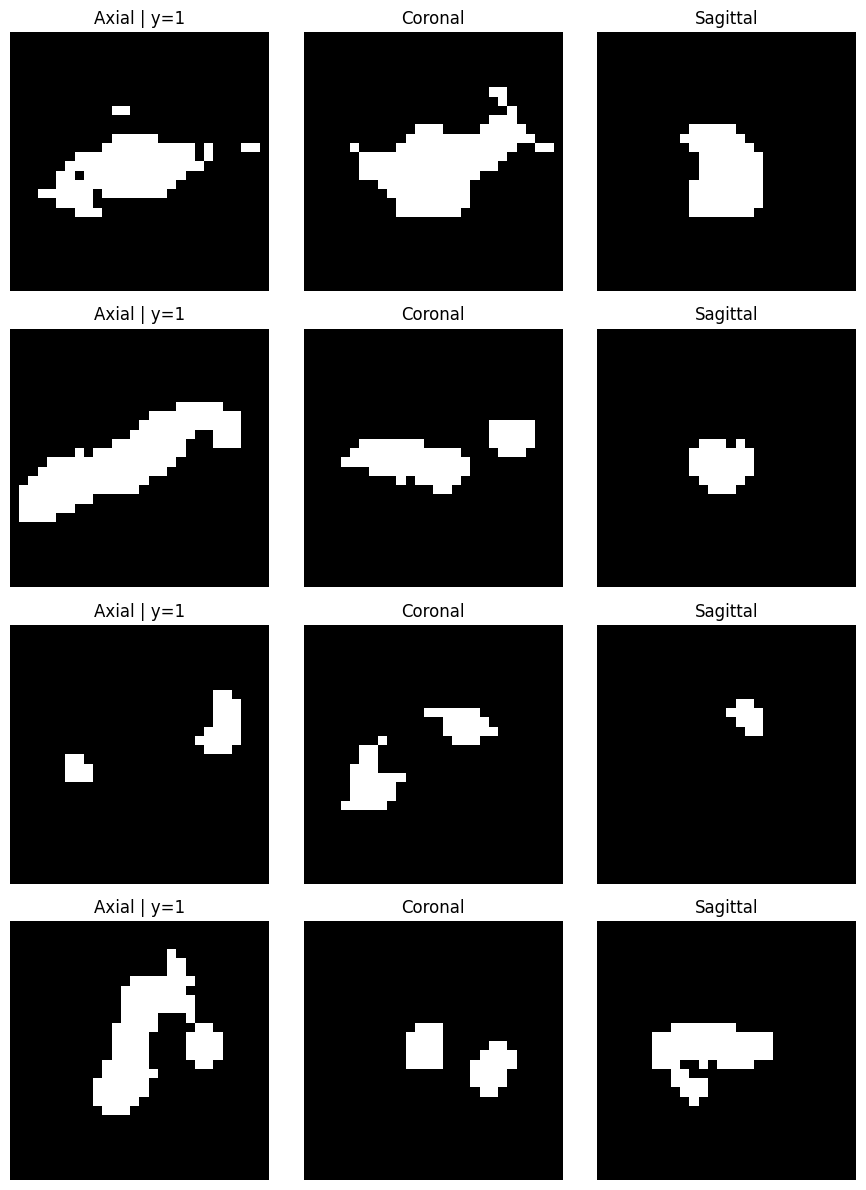

In [ ]:

#   5) Quick data sanity check / visualization
def show_middle_slices(dataset, n=4):
    fig, axes = plt.subplots(n, 3, figsize=(9, 3*n))
    for row in range(n):
        volume, label = dataset[row]
        vol = volume[0].numpy()
        z, y, x = vol.shape[0]//2, vol.shape[1]//2, vol.shape[2]//2
        axes[row, 0].imshow(vol[z], cmap="gray")
        axes[row, 0].set_title(f"Axial | y={label}")
        axes[row, 1].imshow(vol[:, y, :], cmap="gray")
        axes[row, 1].set_title("Coronal")
        axes[row, 2].imshow(vol[:, :, x], cmap="gray")
        axes[row, 2].set_title("Sagittal")
        for c in range(3):
            axes[row, c].axis("off")
    plt.tight_layout()
    plt.show()

show_middle_slices(train_ds, n=4)


In [ ]:

#   6) 3D corruption / augmentation utilities
def _rotation_matrix_xyz(rx, ry, rz, device):
    """Create a 3x3 rotation matrix from Euler angles in radians."""
    cx, sx = torch.cos(rx), torch.sin(rx)
    cy, sy = torch.cos(ry), torch.sin(ry)
    cz, sz = torch.cos(rz), torch.sin(rz)

    Rx = torch.tensor([
        [1.0, 0.0, 0.0],
        [0.0, cx.item(), -sx.item()],
        [0.0, sx.item(),  cx.item()],
    ], dtype=torch.float32, device=device)

    Ry = torch.tensor([
        [ cy.item(), 0.0, sy.item()],
        [ 0.0,       1.0, 0.0],
        [-sy.item(), 0.0, cy.item()],
    ], dtype=torch.float32, device=device)

    Rz = torch.tensor([
        [cz.item(), -sz.item(), 0.0],
        [sz.item(),  cz.item(), 0.0],
        [0.0,        0.0,       1.0],
    ], dtype=torch.float32, device=device)

    return Rz @ Ry @ Rx

def apply_random_rotation_3d(volumes: torch.Tensor, max_degrees: float) -> torch.Tensor:
    """
    volumes: [B, 1, D, H, W]
    Samples a random rotation for each volume with angles in [-max_degrees, +max_degrees].
    """
    if max_degrees <= 0:
        return volumes

    B = volumes.shape[0]
    device = volumes.device
    theta = torch.zeros((B, 3, 4), dtype=torch.float32, device=device)

    for i in range(B):
        angles_deg = torch.empty(3, device=device).uniform_(-max_degrees, max_degrees)
        angles_rad = angles_deg * math.pi / 180.0
        R = _rotation_matrix_xyz(angles_rad[0], angles_rad[1], angles_rad[2], device)
        theta[i, :, :3] = R

    grid = F.affine_grid(theta, size=volumes.size(), align_corners=False)
    rotated = F.grid_sample(
        volumes,
        grid,
        mode="bilinear",
        padding_mode="zeros",
        align_corners=False,
    )
    return rotated.clamp(0.0, 1.0)

def apply_gaussian_noise(volumes: torch.Tensor, std: float) -> torch.Tensor:
    if std <= 0:
        return volumes
    noisy = volumes + torch.randn_like(volumes) * std
    return noisy.clamp(0.0, 1.0)

def apply_shift(volumes: torch.Tensor, rotation_deg: float = 0.0, noise_std: float = 0.0) -> torch.Tensor:
    shifted = volumes
    if rotation_deg > 0:
        shifted = apply_random_rotation_3d(shifted, rotation_deg)
    if noise_std > 0:
        shifted = apply_gaussian_noise(shifted, noise_std)
    return shifted

def apply_train_augmentation(volumes: torch.Tensor, cfg: TrainConfig) -> torch.Tensor:
    if not cfg.robust_train:
        return volumes
    return apply_shift(volumes, rotation_deg=cfg.train_rotation_deg, noise_std=cfg.train_noise_std)


In [ ]:

#   7) Voxel -> point-cloud conversion
def volume_to_point_cloud(volume: torch.Tensor, point_cfg: PointConfig) -> torch.Tensor:
    """
    Convert a single volume [1, D, H, W] into a fixed-size point set [N, C].
    Salient voxels are extracted via thresholding; if too few survive, we fallback to top-k.
    Coordinates are normalized and optionally the intensity is appended as a feature.
    """
    assert volume.ndim == 4 and volume.shape[0] == 1
    v = volume[0]
    D, H, W = v.shape
    flat = v.reshape(-1)

    candidate_idx = torch.nonzero(flat >= point_cfg.threshold, as_tuple=False).squeeze(1)

    min_candidates = max(32, int(point_cfg.num_points * point_cfg.min_candidate_ratio))
    if candidate_idx.numel() < min_candidates:
        k = min(max(point_cfg.num_points, min_candidates), flat.numel())
        candidate_idx = torch.topk(flat, k=k, largest=True).indices

    cand_vals = flat[candidate_idx].clamp_min(1e-6)

    if candidate_idx.numel() >= point_cfg.num_points:
        if point_cfg.weighted_sampling:
            chosen_local = torch.multinomial(cand_vals, point_cfg.num_points, replacement=False)
        else:
            perm = torch.randperm(candidate_idx.numel(), device=volume.device)[:point_cfg.num_points]
            chosen_local = perm
        chosen_idx = candidate_idx[chosen_local]
    else:
        if point_cfg.weighted_sampling:
            chosen_local = torch.multinomial(cand_vals, point_cfg.num_points, replacement=True)
        else:
            chosen_local = torch.randint(0, candidate_idx.numel(), (point_cfg.num_points,), device=volume.device)
        chosen_idx = candidate_idx[chosen_local]

    z = chosen_idx // (H * W)
    rem = chosen_idx % (H * W)
    y = rem // W
    x = rem % W

    coords = torch.stack([x, y, z], dim=1).float()
    denom = torch.tensor([max(W - 1, 1), max(H - 1, 1), max(D - 1, 1)], device=coords.device).float()
    coords = 2.0 * (coords / denom) - 1.0

    coords = coords - coords.mean(dim=0, keepdim=True)
    scale = coords.norm(dim=1).max().clamp_min(1e-6)
    coords = coords / scale

    if point_cfg.include_intensity:
        intensity = flat[chosen_idx].unsqueeze(1)
        points = torch.cat([coords, intensity], dim=1)
    else:
        points = coords

    return points

def volumes_to_point_batch(volumes: torch.Tensor, point_cfg: PointConfig) -> torch.Tensor:
    pts = [volume_to_point_cloud(volumes[i], point_cfg) for i in range(volumes.shape[0])]
    return torch.stack(pts, dim=0)

sample_volume, sample_label = train_ds[0]
sample_points = volume_to_point_cloud(sample_volume, POINT_MAIN_CFG)
print("Sample volume shape:", tuple(sample_volume.shape))
print("Sample point cloud shape:", tuple(sample_points.shape))


Sample volume shape: (1, 28, 28, 28)
Sample point cloud shape: (1024, 4)


In [ ]:

#   8) Model definitions
class VoxelCNN3D(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),

            nn.Conv3d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool3d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

class TransformNet(nn.Module):
    def __init__(self, k: int = 3):
        super().__init__()
        self.k = k
        self.mlp = nn.Sequential(
            nn.Conv1d(k, 64, 1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Conv1d(64, 128, 1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 256, 1),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
        )
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Linear(64, k * k),
        )
        nn.init.zeros_(self.fc[-1].weight)
        nn.init.zeros_(self.fc[-1].bias)

    def forward(self, x):
        B = x.shape[0]
        feat = self.mlp(x)
        feat = torch.max(feat, dim=2).values
        mat = self.fc(feat)
        identity = torch.eye(self.k, device=x.device, dtype=x.dtype).view(1, self.k * self.k).repeat(B, 1)
        mat = mat + identity
        return mat.view(B, self.k, self.k)

class PointNetClassifier(nn.Module):
    def __init__(self, input_dim: int = 4, num_classes: int = 2, use_input_transform: bool = True):
        super().__init__()
        self.use_input_transform = use_input_transform
        self.input_tnet = TransformNet(k=3) if use_input_transform else None

        self.shared_mlp = nn.Sequential(
            nn.Conv1d(input_dim, 64, 1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Conv1d(64, 128, 1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 256, 1),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        if self.use_input_transform:
            xyz = x[:, :3, :]
            T = self.input_tnet(xyz)
            xyz = torch.bmm(T, xyz)
            if x.shape[1] > 3:
                x = torch.cat([xyz, x[:, 3:, :]], dim=1)
            else:
                x = xyz

        feat = self.shared_mlp(x)
        global_feat = torch.max(feat, dim=2).values
        return self.classifier(global_feat)

def build_model(pipeline: str, point_cfg: Optional[PointConfig] = None) -> nn.Module:
    if pipeline == "voxel":
        return VoxelCNN3D(num_classes=2).to(DEVICE)
    if pipeline == "point":
        assert point_cfg is not None
        input_dim = 4 if point_cfg.include_intensity else 3
        return PointNetClassifier(input_dim=input_dim, num_classes=2, use_input_transform=True).to(DEVICE)
    raise ValueError(f"Unknown pipeline: {pipeline}")


In [ ]:

#   9) Training / evaluation utilities
def prepare_inputs(volumes: torch.Tensor, pipeline: str, point_cfg: Optional[PointConfig] = None) -> torch.Tensor:
    if pipeline == "voxel":
        return volumes
    if pipeline == "point":
        assert point_cfg is not None
        return volumes_to_point_batch(volumes, point_cfg)
    raise ValueError(f"Unknown pipeline: {pipeline}")

def probs_from_logits(logits: torch.Tensor) -> torch.Tensor:
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
    pipeline: str,
    point_cfg: Optional[PointConfig] = None,
    corruption: Optional[dict] = None,
    tta_cfg: Optional[TTAConfig] = None,
) -> dict:
    model.eval()
    all_labels = []
    all_probs = []
    all_losses = []
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    for volumes, labels in tqdm(loader, desc=f"Eval [{pipeline}]", leave=False):
        volumes = volumes.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        reps = tta_cfg.reps if (tta_cfg is not None and tta_cfg.enabled) else 1
        probs_accum = 0.0
        loss_accum = 0.0

        for _ in range(reps):
            v = volumes.clone()

            if corruption is not None:
                v = apply_shift(
                    v,
                    rotation_deg=float(corruption.get("rotation_deg", 0.0)),
                    noise_std=float(corruption.get("noise_std", 0.0)),
                )

            if tta_cfg is not None and tta_cfg.enabled:
                v = apply_shift(v, rotation_deg=tta_cfg.rotation_deg, noise_std=tta_cfg.noise_std)

            x = prepare_inputs(v, pipeline, point_cfg)
            logits = model(x)
            probs = probs_from_logits(logits)
            loss = criterion(logits, labels)

            probs_accum = probs_accum + probs
            loss_accum = loss_accum + loss.detach()

        probs_accum = probs_accum / reps
        loss_accum = loss_accum / reps

        all_labels.append(labels.detach().cpu())
        all_probs.append(probs_accum.detach().cpu())
        all_losses.append(loss_accum.item())

    y_true = torch.cat(all_labels).numpy()
    y_prob = torch.cat(all_probs).numpy()
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "loss": float(np.mean(all_losses)),
        "auroc": float(roc_auc_score(y_true, y_prob)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "n_samples": int(len(y_true)),
    }
    return metrics

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    pipeline: str,
    train_cfg: TrainConfig,
    point_cfg: Optional[PointConfig] = None,
) -> float:
    model.train()
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    running_losses = []

    amp_enabled = bool(train_cfg.use_amp and DEVICE.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    for volumes, labels in tqdm(loader, desc=f"Train [{pipeline}]", leave=False):
        volumes = volumes.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        volumes = apply_train_augmentation(volumes, train_cfg)
        x = prepare_inputs(volumes, pipeline, point_cfg)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=amp_enabled):
            logits = model(x)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_losses.append(loss.item())

    return float(np.mean(running_losses))

def fit_model(
    exp_name: str,
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    pipeline: str,
    train_cfg: TrainConfig,
    point_cfg: Optional[PointConfig] = None,
) -> Tuple[nn.Module, pd.DataFrame, dict]:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=train_cfg.lr,
        weight_decay=train_cfg.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )

    history = []
    best_state = None
    best_metric = -np.inf
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, train_cfg.epochs + 1):
        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            pipeline=pipeline,
            train_cfg=train_cfg,
            point_cfg=point_cfg,
        )

        val_metrics = evaluate_model(
            model=model,
            loader=val_loader,
            pipeline=pipeline,
            point_cfg=point_cfg,
            corruption=None,
            tta_cfg=None,
        )

        scheduler.step(val_metrics["auroc"])

        row = {
            "experiment": exp_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_auroc": val_metrics["auroc"],
            "val_accuracy": val_metrics["accuracy"],
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"[{exp_name}] Epoch {epoch:02d}/{train_cfg.epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_auroc={val_metrics['auroc']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f}"
        )

        if val_metrics["auroc"] > best_metric:
            best_metric = val_metrics["auroc"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= train_cfg.patience:
            print(f"Early stopping triggered for {exp_name} at epoch {epoch}.")
            break

    assert best_state is not None, "Training never produced a best state."
    model.load_state_dict(best_state)

    ckpt_path = CKPT_DIR / f"{exp_name}.pt"
    torch.save(
        {
            "experiment": exp_name,
            "pipeline": pipeline,
            "train_cfg": asdict(train_cfg),
            "point_cfg": asdict(point_cfg) if point_cfg is not None else None,
            "best_epoch": best_epoch,
            "best_val_auroc": best_metric,
            "state_dict": model.state_dict(),
        },
        ckpt_path,
    )

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(TABLE_DIR / f"{exp_name}_history.csv", index=False)

    summary = {
        "experiment": exp_name,
        "pipeline": pipeline,
        "best_epoch": best_epoch,
        "best_val_auroc": float(best_metric),
        "checkpoint": str(ckpt_path),
    }
    return model, hist_df, summary


In [ ]:

#   10) Robustness benchmark utilities
def benchmark_model(
    exp_name: str,
    model: nn.Module,
    loader: DataLoader,
    pipeline: str,
    point_cfg: Optional[PointConfig] = None,
    tta_cfg: Optional[TTAConfig] = None,
) -> pd.DataFrame:
    rows = []

    clean_metrics = evaluate_model(
        model=model,
        loader=loader,
        pipeline=pipeline,
        point_cfg=point_cfg,
        corruption=None,
        tta_cfg=tta_cfg,
    )
    rows.append({
        "experiment": exp_name,
        "pipeline": pipeline,
        "shift_type": "clean",
        "severity": 0,
        "rotation_deg": 0.0,
        "noise_std": 0.0,
        **clean_metrics,
    })

    for i, deg in enumerate(ROTATION_SEVERITIES[1:], start=1):
        metrics = evaluate_model(
            model=model,
            loader=loader,
            pipeline=pipeline,
            point_cfg=point_cfg,
            corruption={"rotation_deg": deg, "noise_std": 0.0},
            tta_cfg=tta_cfg,
        )
        rows.append({
            "experiment": exp_name,
            "pipeline": pipeline,
            "shift_type": "rotation",
            "severity": i,
            "rotation_deg": deg,
            "noise_std": 0.0,
            **metrics,
        })

    for i, std in enumerate(NOISE_SEVERITIES[1:], start=1):
        metrics = evaluate_model(
            model=model,
            loader=loader,
            pipeline=pipeline,
            point_cfg=point_cfg,
            corruption={"rotation_deg": 0.0, "noise_std": std},
            tta_cfg=tta_cfg,
        )
        rows.append({
            "experiment": exp_name,
            "pipeline": pipeline,
            "shift_type": "noise",
            "severity": i,
            "rotation_deg": 0.0,
            "noise_std": std,
            **metrics,
        })

    df = pd.DataFrame(rows)
    clean_auroc = float(df.loc[df["shift_type"] == "clean", "auroc"].iloc[0])
    clean_acc = float(df.loc[df["shift_type"] == "clean", "accuracy"].iloc[0])
    df["auroc_drop_from_clean"] = clean_auroc - df["auroc"]
    df["accuracy_drop_from_clean"] = clean_acc - df["accuracy"]
    return df

def plot_metric_curves(df: pd.DataFrame, metric: str, title_prefix: str, save_name: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    rot_df = df[df["shift_type"].isin(["clean", "rotation"])].copy()
    noise_df = df[df["shift_type"].isin(["clean", "noise"])].copy()

    for exp_name, sub in rot_df.groupby("experiment"):
        x = [0.0] + sub.loc[sub["shift_type"] == "rotation", "rotation_deg"].tolist()
        y = [sub.loc[sub["shift_type"] == "clean", metric].iloc[0]] + sub.loc[sub["shift_type"] == "rotation", metric].tolist()
        axes[0].plot(x, y, marker="o", label=exp_name)

    axes[0].set_title(f"{title_prefix}: Rotation")
    axes[0].set_xlabel("Max random rotation (degrees)")
    axes[0].set_ylabel(metric.upper())
    axes[0].grid(True)
    axes[0].legend()

    for exp_name, sub in noise_df.groupby("experiment"):
        x = [0.0] + sub.loc[sub["shift_type"] == "noise", "noise_std"].tolist()
        y = [sub.loc[sub["shift_type"] == "clean", metric].iloc[0]] + sub.loc[sub["shift_type"] == "noise", metric].tolist()
        axes[1].plot(x, y, marker="o", label=exp_name)

    axes[1].set_title(f"{title_prefix}: Additive Noise")
    axes[1].set_xlabel("Gaussian noise std")
    axes[1].set_ylabel(metric.upper())
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    path = FIG_DIR / save_name
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to: {path}")


In [ ]:

#   11) Main experiment runner
def run_single_experiment(
    exp_name: str,
    pipeline: str,
    train_cfg: TrainConfig,
    point_cfg: Optional[PointConfig] = None,
    use_tta: bool = False,
) -> Tuple[nn.Module, pd.DataFrame, pd.DataFrame]:
    model = build_model(pipeline, point_cfg=point_cfg)

    model, hist_df, summary = fit_model(
        exp_name=exp_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        pipeline=pipeline,
        train_cfg=train_cfg,
        point_cfg=point_cfg,
    )

    print("Training summary:", summary)

    tta_cfg = TTAConfig(enabled=use_tta) if use_tta else TTAConfig(enabled=False)

    benchmark_df = benchmark_model(
        exp_name=exp_name,
        model=model,
        loader=test_loader,
        pipeline=pipeline,
        point_cfg=point_cfg,
        tta_cfg=tta_cfg,
    )
    benchmark_path = TABLE_DIR / f"{exp_name}_benchmark.csv"
    benchmark_df.to_csv(benchmark_path, index=False)
    print(f"Saved benchmark to: {benchmark_path}")

    return model, hist_df, benchmark_df


## 12) Core experiments

The next cells run:
- `voxel_clean`
- `point_clean_xyzI_1024`
- `voxel_robust`
- `point_robust_xyzI_1024`

Then the notebook runs point-construction ablations:
- `xyz` vs. `xyz+I`
- `N=512` vs. `N=1024`

For a quick first run in Colab, reduce `BASE_TRAIN_CFG.epochs` and `ROBUST_TRAIN_CFG.epochs` before launching the experiments.


In [ ]:

#   12A) Optional quick-run override
# Uncomment these lines if you want a faster smoke test before the full run.
# BASE_TRAIN_CFG.epochs = 6
# ROBUST_TRAIN_CFG.epochs = 6
# BASE_TRAIN_CFG.patience = 3
# ROBUST_TRAIN_CFG.patience = 3

print("Base config:", asdict(BASE_TRAIN_CFG))
print("Robust config:", asdict(ROBUST_TRAIN_CFG))


Base config: {'batch_size': 64, 'num_workers': 2, 'epochs': 25, 'lr': 0.001, 'weight_decay': 0.0001, 'patience': 6, 'use_amp': True, 'robust_train': False, 'train_rotation_deg': 25.0, 'train_noise_std': 0.08}
Robust config: {'batch_size': 64, 'num_workers': 2, 'epochs': 25, 'lr': 0.001, 'weight_decay': 0.0001, 'patience': 6, 'use_amp': True, 'robust_train': True, 'train_rotation_deg': 25.0, 'train_noise_std': 0.08}


In [ ]:

#   12B) Train the required baseline models
all_histories = []
all_benchmarks = []
trained_models = {}

voxel_clean_model, voxel_clean_hist, voxel_clean_bench = run_single_experiment(
    exp_name="voxel_clean",
    pipeline="voxel",
    train_cfg=BASE_TRAIN_CFG,
    point_cfg=None,
    use_tta=False,
)
trained_models["voxel_clean"] = voxel_clean_model
all_histories.append(voxel_clean_hist)
all_benchmarks.append(voxel_clean_bench)

point_clean_model, point_clean_hist, point_clean_bench = run_single_experiment(
    exp_name="point_clean_xyzI_1024",
    pipeline="point",
    train_cfg=BASE_TRAIN_CFG,
    point_cfg=POINT_MAIN_CFG,
    use_tta=False,
)
trained_models["point_clean_xyzI_1024"] = point_clean_model
all_histories.append(point_clean_hist)
all_benchmarks.append(point_clean_bench)


/tmp/ipykernel_656/3331363014.py:89: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


Train [voxel]:   0%|          | 0/21 [00:00<?, ?it/s]

/tmp/ipykernel_656/3331363014.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


Eval [voxel]:   0%|          | 0/3 [00:00<?, ?it/s]

[voxel_clean] Epoch 01/25 | train_loss=0.6339 | val_auroc=0.8314 | val_acc=0.8848


...

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Saved benchmark to: /content/vesselmnist3d_project/outputs/tables/point_clean_xyzI_1024_benchmark.csv


In [ ]:

#   12C) Train the required robust-training models
voxel_robust_model, voxel_robust_hist, voxel_robust_bench = run_single_experiment(
    exp_name="voxel_robust",
    pipeline="voxel",
    train_cfg=ROBUST_TRAIN_CFG,
    point_cfg=None,
    use_tta=False,
)
trained_models["voxel_robust"] = voxel_robust_model
all_histories.append(voxel_robust_hist)
all_benchmarks.append(voxel_robust_bench)

point_robust_model, point_robust_hist, point_robust_bench = run_single_experiment(
    exp_name="point_robust_xyzI_1024",
    pipeline="point",
    train_cfg=ROBUST_TRAIN_CFG,
    point_cfg=POINT_MAIN_CFG,
    use_tta=False,
)
trained_models["point_robust_xyzI_1024"] = point_robust_model
all_histories.append(point_robust_hist)
all_benchmarks.append(point_robust_bench)


/tmp/ipykernel_656/3331363014.py:89: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


Train [voxel]:   0%|          | 0/21 [00:00<?, ?it/s]

/tmp/ipykernel_656/3331363014.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


Eval [voxel]:   0%|          | 0/3 [00:00<?, ?it/s]

[voxel_robust] Epoch 01/25 | train_loss=0.6306 | val_auroc=0.7851 | val_acc=0.8848


...

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Saved benchmark to: /content/vesselmnist3d_project/outputs/tables/point_robust_xyzI_1024_benchmark.csv


In [ ]:

#   13) Point pipeline ablations
for point_cfg in POINT_ABLATIONS:
    ablation_name = f"point_ablation_xyz{'I' if point_cfg.include_intensity else ''}_{point_cfg.num_points}"
    print("\nRunning ablation:", ablation_name, asdict(point_cfg))

    ablation_model, ablation_hist, ablation_bench = run_single_experiment(
        exp_name=ablation_name,
        pipeline="point",
        train_cfg=BASE_TRAIN_CFG,
        point_cfg=point_cfg,
        use_tta=False,
    )
    trained_models[ablation_name] = ablation_model
    all_histories.append(ablation_hist)
    all_benchmarks.append(ablation_bench)



Running ablation: point_ablation_xyz_512 {'num_points': 512, 'include_intensity': False, 'threshold': 0.1, 'min_candidate_ratio': 0.25, 'weighted_sampling': True}


/tmp/ipykernel_656/3331363014.py:89: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


Train [point]:   0%|          | 0/21 [00:00<?, ?it/s]

/tmp/ipykernel_656/3331363014.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


Eval [point]:   0%|          | 0/3 [00:00<?, ?it/s]

...

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Saved benchmark to: /content/vesselmnist3d_project/outputs/tables/point_ablation_xyzI_1024_benchmark.csv


In [ ]:

#   14) Aggregate and inspect training histories / benchmarks
history_df = pd.concat(all_histories, ignore_index=True)
benchmark_df = pd.concat(all_benchmarks, ignore_index=True)

history_df.to_csv(TABLE_DIR / "all_histories.csv", index=False)
benchmark_df.to_csv(TABLE_DIR / "all_benchmarks.csv", index=False)

print("History table saved to:", TABLE_DIR / "all_histories.csv")
print("Benchmark table saved to:", TABLE_DIR / "all_benchmarks.csv")

display(history_df.tail())
display(benchmark_df)


History table saved to: /content/vesselmnist3d_project/outputs/tables/all_histories.csv
Benchmark table saved to: /content/vesselmnist3d_project/outputs/tables/all_benchmarks.csv


,experiment,epoch,train_loss,val_loss,val_auroc,val_accuracy,lr
127,point_ablation_xyzI_1024,21,0.043425,0.429637,0.898870,0.869110,0.00025
128,point_ablation_xyzI_1024,22,0.043266,0.441196,0.893760,0.869110,0.00025
129,point_ablation_xyzI_1024,23,0.028886,0.394096,0.912049,0.879581,0.00025
130,point_ablation_xyzI_1024,24,0.032008,0.488120,0.898601,0.890052,0.00025
131,point_ablation_xyzI_1024,25,0.030921,0.430333,0.895643,0.905759,0.00025


,experiment,pipeline,shift_type,severity,rotation_deg,noise_std,loss,auroc,accuracy,n_samples,auroc_drop_from_clean,accuracy_drop_from_clean
0,voxel_clean,voxel,clean,0,0.0,0.00,0.380591,0.913974,0.866492,382,0.000000,0.000000
1,voxel_clean,voxel,rotation,1,15.0,0.00,0.497913,0.848185,0.913613,382,0.065789,-0.047120
2,voxel_clean,voxel,rotation,2,30.0,0.00,0.642635,0.765109,0.890052,382,0.148865,-0.023560
3,voxel_clean,voxel,rotation,3,45.0,0.00,0.749123,0.657131,0.887435,382,0.256843,-0.020942
4,voxel_clean,voxel,noise,1,0.0,0.03,0.512228,0.915072,0.824607,382,-0.001098,0.041885
5,voxel_clean,voxel,noise,2,0.0,0.06,0.353193,0.909378,0.861257,382,0.004596,0.005236
6,voxel_clean,voxel,noise,3,0.0,0.10,0.462676,0.919599,0.905759,382,-0.005625,-0.039267
7,point_clean_xyzI_1024,point,clean,0,0.0,0.00,0.403103,0.906702,0.827225,382,0.000000,0.000000
8,point_clean_xyzI_1024,point,rotation,1,15.0,0.00,0.631475,0.823901,0.738220,382,0.082802,0.089005
9,point_clean_xyzI_1024,point,rotation,2,30.0,0.00,0.731564,0.728476,0.719895,382,0.178226,0.107330


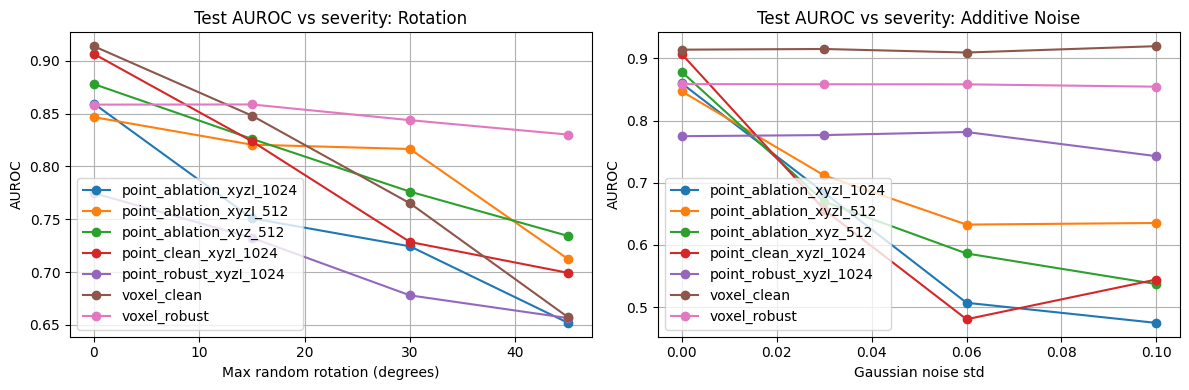

Saved plot to: /content/vesselmnist3d_project/outputs/figures/benchmark_auroc_curves.png


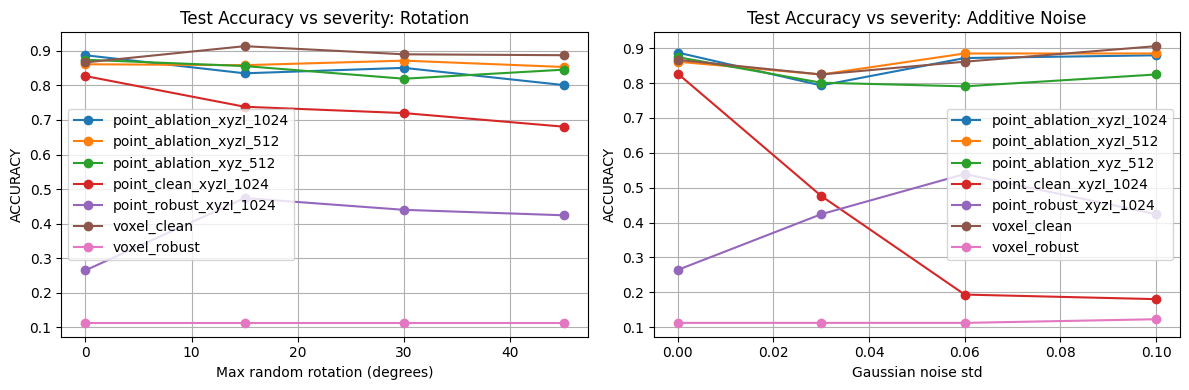

Saved plot to: /content/vesselmnist3d_project/outputs/figures/benchmark_accuracy_curves.png


In [ ]:

#   15) Plot robustness curves
plot_metric_curves(
    benchmark_df,
    metric="auroc",
    title_prefix="Test AUROC vs severity",
    save_name="benchmark_auroc_curves.png",
)

plot_metric_curves(
    benchmark_df,
    metric="accuracy",
    title_prefix="Test Accuracy vs severity",
    save_name="benchmark_accuracy_curves.png",
)


In [ ]:

#   16) Summary tables: clean performance and robustness drop
clean_summary = benchmark_df[benchmark_df["shift_type"] == "clean"].copy()
clean_summary = clean_summary.sort_values(["auroc", "accuracy"], ascending=False)

drop_summary = (
    benchmark_df[benchmark_df["shift_type"] != "clean"]
    .groupby(["experiment", "pipeline", "shift_type"], as_index=False)[
        ["auroc_drop_from_clean", "accuracy_drop_from_clean"]
    ]
    .mean()
    .sort_values(["shift_type", "auroc_drop_from_clean"])
)

clean_summary.to_csv(TABLE_DIR / "clean_summary.csv", index=False)
drop_summary.to_csv(TABLE_DIR / "robustness_drop_summary.csv", index=False)

print("=== Clean summary ===")
display(clean_summary[["experiment", "pipeline", "auroc", "accuracy", "loss"]])

print("=== Average robustness drop from clean ===")
display(drop_summary)


=== Clean summary ===


,experiment,pipeline,auroc,accuracy,loss
0,voxel_clean,voxel,0.913974,0.866492,0.380591
7,point_clean_xyzI_1024,point,0.906702,0.827225,0.403103
28,point_ablation_xyz_512,point,0.878096,0.874346,0.337936
42,point_ablation_xyzI_1024,point,0.859642,0.887435,0.411598
14,voxel_robust,voxel,0.858613,0.112565,5.221162
35,point_ablation_xyzI_512,point,0.846745,0.861257,0.359776
21,point_robust_xyzI_1024,point,0.774782,0.264398,1.727921


=== Average robustness drop from clean ===


,experiment,pipeline,shift_type,auroc_drop_from_clean,accuracy_drop_from_clean
10,voxel_clean,voxel,noise,-0.000709,0.002618
12,voxel_robust,voxel,noise,0.001624,-0.003490
8,point_robust_xyzI_1024,point,noise,0.007866,-0.198080
2,point_ablation_xyzI_512,point,noise,0.186938,-0.003490
4,point_ablation_xyz_512,point,noise,0.280602,0.068935
0,point_ablation_xyzI_1024,point,noise,0.304635,0.039267
6,point_clean_xyzI_1024,point,noise,0.346345,0.543630
13,voxel_robust,voxel,rotation,0.014338,0.000000
3,point_ablation_xyzI_512,point,rotation,0.063570,0.000000
9,point_robust_xyzI_1024,point,rotation,0.085866,-0.181501


## 17) Optional Milestone 4: Test-time augmentation (TTA)

The next cell evaluates TTA on the main robust models:

- `voxel_robust + TTA`
- `point_robust_xyzI_1024 + TTA`

TTA here means averaging predictions over several additional random rotation+noise views at test time.


In [ ]:

#   17A) Run TTA on the robust models
tta_benchmarks = []

tta_cfg = TTAConfig(enabled=True, reps=8, rotation_deg=10.0, noise_std=0.03)
print("Using TTA config:", asdict(tta_cfg))

voxel_robust_tta_df = benchmark_model(
    exp_name="voxel_robust_tta",
    model=trained_models["voxel_robust"],
    loader=test_loader,
    pipeline="voxel",
    point_cfg=None,
    tta_cfg=tta_cfg,
)
tta_benchmarks.append(voxel_robust_tta_df)

point_robust_tta_df = benchmark_model(
    exp_name="point_robust_xyzI_1024_tta",
    model=trained_models["point_robust_xyzI_1024"],
    loader=test_loader,
    pipeline="point",
    point_cfg=POINT_MAIN_CFG,
    tta_cfg=tta_cfg,
)
tta_benchmarks.append(point_robust_tta_df)

tta_df = pd.concat(tta_benchmarks, ignore_index=True)
tta_df.to_csv(TABLE_DIR / "tta_benchmarks.csv", index=False)

display(tta_df)


Using TTA config: {'enabled': True, 'reps': 8, 'rotation_deg': 10.0, 'noise_std': 0.03}


Eval [voxel]:   0%|          | 0/6 [00:00<?, ?it/s]

Eval [voxel]:   0%|          | 0/6 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fd562dc47c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7fd562dc47c0>
^^Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^self._shutdown_workers()^^
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():
A

Eval [voxel]:   0%|          | 0/6 [00:00<?, ?it/s]

...

Eval [point]:   0%|          | 0/6 [00:10<?, ?it/s]

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

Eval [point]:   0%|          | 0/6 [00:00<?, ?it/s]

,experiment,pipeline,shift_type,severity,rotation_deg,noise_std,loss,auroc,accuracy,n_samples,auroc_drop_from_clean,accuracy_drop_from_clean
0,voxel_robust_tta,voxel,clean,0,0.0,0.00,3.213408,0.866296,0.112565,382,0.000000,0.000000
1,voxel_robust_tta,voxel,rotation,1,15.0,0.00,2.563875,0.871853,0.117801,382,-0.005557,-0.005236
2,voxel_robust_tta,voxel,rotation,2,30.0,0.00,2.572577,0.874803,0.115183,382,-0.008507,-0.002618
3,voxel_robust_tta,voxel,rotation,3,45.0,0.00,2.604391,0.868766,0.115183,382,-0.002470,-0.002618
4,voxel_robust_tta,voxel,noise,1,0.0,0.03,3.200778,0.870275,0.112565,382,-0.003979,0.000000
5,voxel_robust_tta,voxel,noise,2,0.0,0.06,3.236400,0.870961,0.112565,382,-0.004665,0.000000
6,voxel_robust_tta,voxel,noise,3,0.0,0.10,3.315655,0.870961,0.112565,382,-0.004665,0.000000
7,point_robust_xyzI_1024_tta,point,clean,0,0.0,0.00,0.980704,0.756328,0.484293,382,0.000000,0.000000
8,point_robust_xyzI_1024_tta,point,rotation,1,15.0,0.00,0.829727,0.776223,0.554974,382,-0.019894,-0.070681
9,point_robust_xyzI_1024_tta,point,rotation,2,30.0,0.00,0.861393,0.769706,0.520942,382,-0.013377,-0.036649


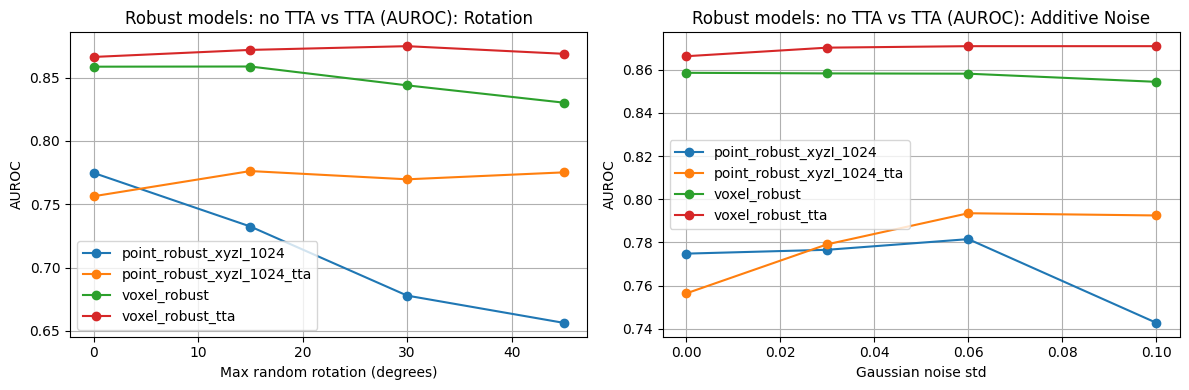

Saved plot to: /content/vesselmnist3d_project/outputs/figures/robust_vs_tta_auroc.png


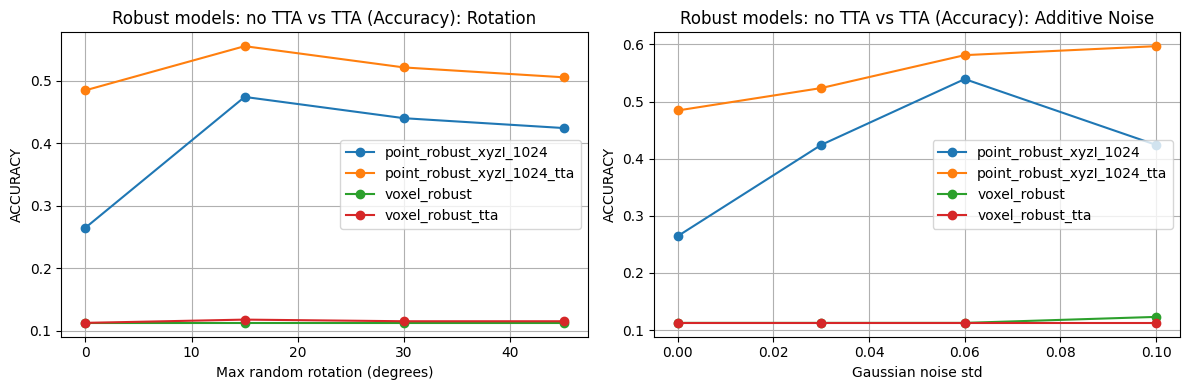

Saved plot to: /content/vesselmnist3d_project/outputs/figures/robust_vs_tta_accuracy.png


In [ ]:

#   17B) Compare no-TTA vs TTA for the robust models
comparison_df = pd.concat([
    benchmark_df[benchmark_df["experiment"].isin(["voxel_robust", "point_robust_xyzI_1024"])],
    tta_df
], ignore_index=True)

comparison_df.to_csv(TABLE_DIR / "robust_vs_tta_comparison.csv", index=False)

plot_metric_curves(
    comparison_df,
    metric="auroc",
    title_prefix="Robust models: no TTA vs TTA (AUROC)",
    save_name="robust_vs_tta_auroc.png",
)

plot_metric_curves(
    comparison_df,
    metric="accuracy",
    title_prefix="Robust models: no TTA vs TTA (Accuracy)",
    save_name="robust_vs_tta_accuracy.png",
)


In [ ]:

#   18) Export a compact experiment summary JSON
artifact = {
    "dataset": "VesselMNIST3D",
    "train_config_base": asdict(BASE_TRAIN_CFG),
    "train_config_robust": asdict(ROBUST_TRAIN_CFG),
    "point_main_config": asdict(POINT_MAIN_CFG),
    "rotation_severities": ROTATION_SEVERITIES,
    "noise_severities": NOISE_SEVERITIES,
    "output_dir": str(OUT_DIR),
    "tables": sorted([str(p) for p in TABLE_DIR.glob("*.csv")]),
    "figures": sorted([str(p) for p in FIG_DIR.glob("*.png")]),
    "checkpoints": sorted([str(p) for p in CKPT_DIR.glob("*.pt")]),
}
with open(OUT_DIR / "run_artifact_summary.json", "w") as f:
    json.dump(artifact, f, indent=2)

print(json.dumps(artifact, indent=2))


{
  "dataset": "VesselMNIST3D",
  "train_config_base": {
    "batch_size": 64,
    "num_workers": 2,
    "epochs": 25,
    "lr": 0.001,
    "weight_decay": 0.0001,
    "patience": 6,
    "use_amp": true,
    "robust_train": false,
    "train_rotation_deg": 25.0,
    "train_noise_std": 0.08
  },
  "train_config_robust": {
    "batch_size": 64,
    "num_workers": 2,
    "epochs": 25,
    "lr": 0.001,
    "weight_decay": 0.0001,
    "patience": 6,
    "use_amp": true,
    "robust_train": true,
    "train_rotation_deg": 25.0,
    "train_noise_std": 0.08
  },
  "point_main_config": {
    "num_points": 1024,
    "include_intensity": true,
    "threshold": 0.1,
    "min_candidate_ratio": 0.25,
    "weighted_sampling": true
  },
  "rotation_severities": [
    0.0,
    15.0,
    30.0,
    45.0
  ],
  "noise_severities": [
    0.0,
    0.03,
    0.06,
    0.1
  ],
  "output_dir": "/content/vesselmnist3d_project/outputs",
  "tables": [
    "/content/vesselmnist3d_project/outputs/tables/all_benchm

## 19) References

[1] **PointNet**  
   Qi, Su, Mo, and Guibas. *PointNet: Deep Learning on Point Sets for 3D Classification and Segmentation.* CVPR 2017.

[2] **MedMNIST / VesselMNIST3D**  
   Yang et al. *MedMNIST v2: A Large-Scale Lightweight Benchmark for 2D and 3D Biomedical Image Classification.* Scientific Data 2023.


In [ ]:
import shutil
from google.colab import files

folder_to_zip = '/content/vesselmnist3d_project/outputs'
output_filename = 'vesselmnist3d_results.zip'

shutil.make_archive('vesselmnist3d_results', 'zip', folder_to_zip)

files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>